In [145]:
import os
import sys
cwd = os.getcwd()
src_dir = os.path.join(cwd, '..', 'src/')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. General Data Observation

In [146]:
train = pd.read_csv('../data/train.csv')
train

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51


Let's try to get better understanding of features' meaning (unluckily kaggle does not reveal much information about features):
- **id**: just a continious set of numbers representing sample number
- **road_type**: reveals musch or less good understanding of surface the car drove (whether it was highway, country road or whatever)
- **num_lanes**: quantity of one way lanes on the road
- **curvature**: a measure of how curve the road is (higher values represent sharp turns, whereas low values are straight roads)
- **speed_limit**: a maximum speed constraint
- **lightning**: represents how well-lit the road is (whether road lights are used or whatever else)
- **weather**: represents whether conditions (I guess rainy whether is more likely to be accident-risky)
- **road_signs_present**: are there any road signs or not
- **public_road**: just an indicator if a road being public
- **time_of_day**: represents whether it's daytime, evening or whatever
- **holiday**: an indicator if it is a holiday or not (people might be driving drunk on holidays)
- **school_season**: represents whether children are to go to school or have vacations
- **num_reported_accidents**: for now it's a very abstract feature with not much meaning to me

# 2. Let's Dive Into Distributions

This step is kinda important tom understand, as for most algorithms to work proberly we want our distributions be normal (out Gaussian whatever you like more). For this reason we need to do some investigations and decide whether any transfromations are neccessary or not

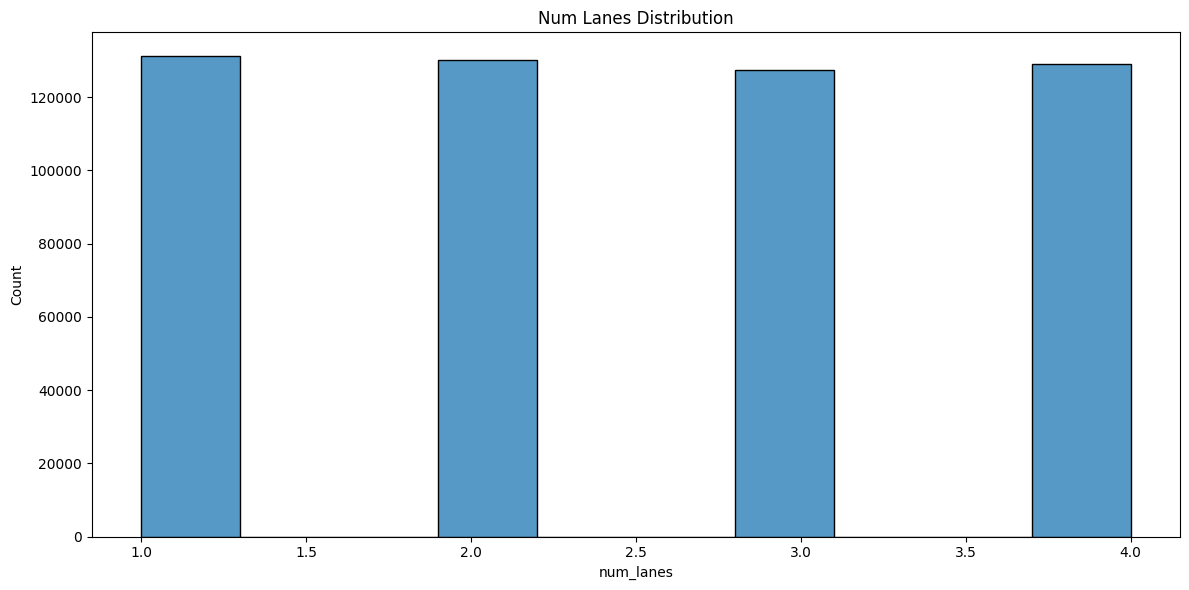

In [147]:
plt.figure(figsize=(12, 6))
sns.histplot(train['num_lanes'], bins=10)
plt.title('Num Lanes Distribution')
plt.tight_layout()
plt.show()

- Soooo it seems that **num_lanes** matches normal distribution and there's nothing to do with this feature

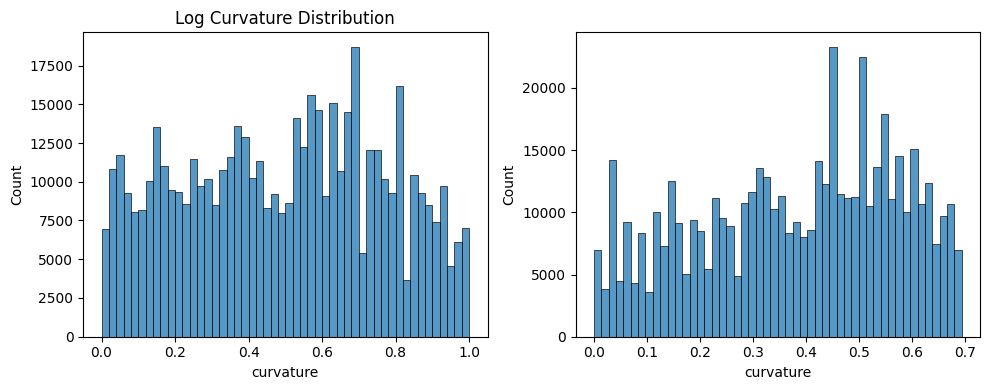

In [148]:
fig, axes = plt.subplots(1, 2, figsize = (10, 4))

sns.histplot(train['curvature'], bins=50, ax=axes[0])
axes[0].set_title('Curvature Distribution')

sns.histplot(np.log1p(train['curvature']), bins=50, ax=axes[1])
axes[0].set_title('Log Curvature Distribution')

plt.tight_layout()
plt.show()

- Well, **curvature** really seems to be strangely distributed, yet log-transformation does not greatly impove the situation 

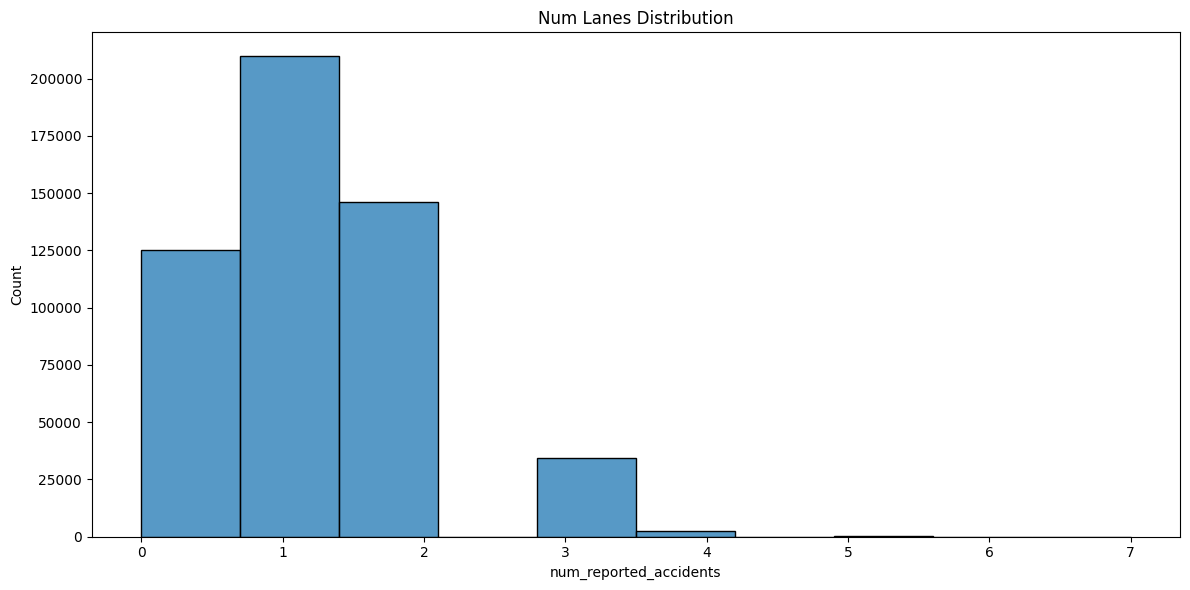

In [149]:
plt.figure(figsize=(12, 6))
sns.histplot(train['num_reported_accidents'], bins=10)
plt.title('Num Lanes Distribution')
plt.tight_layout()
plt.show()

- Nothing really interesting about this.

# 3. Time For Some Aggregations
What we actually are going to do is to aggragate data in order to reveal some more specific dependencies.

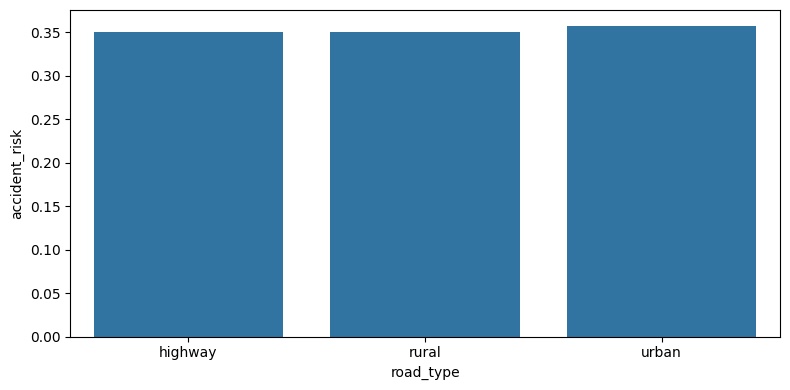

In [150]:
df_road_type = train.groupby(['road_type']).agg(
    {'accident_risk':'mean'}
).reset_index()
plt.figure(figsize=(8, 4))
sns.barplot(x = df_road_type['road_type'], y = df_road_type['accident_risk'])
plt.tight_layout()
plt.show()

- It basically seems that **road_type** alone does not really effect **accident_risk**

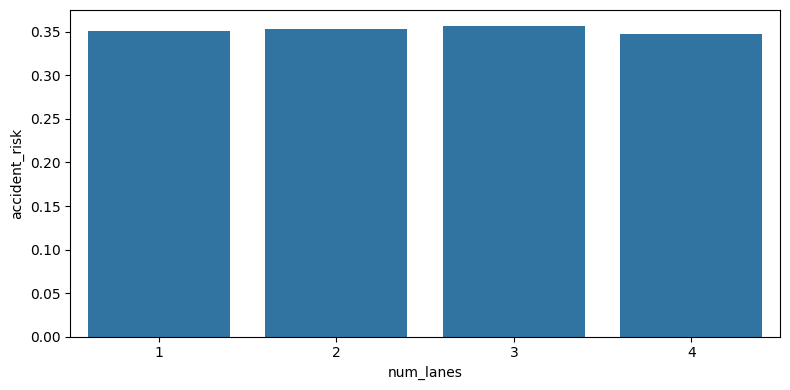

In [151]:
df_num_lanes = train.groupby(['num_lanes']).agg(
    {'accident_risk':'mean'}
).reset_index()
plt.figure(figsize=(8, 4))
sns.barplot(x = df_num_lanes['num_lanes'], y= df_num_lanes['accident_risk'])
plt.tight_layout()
plt.show()

- Well, generally we see the same picture

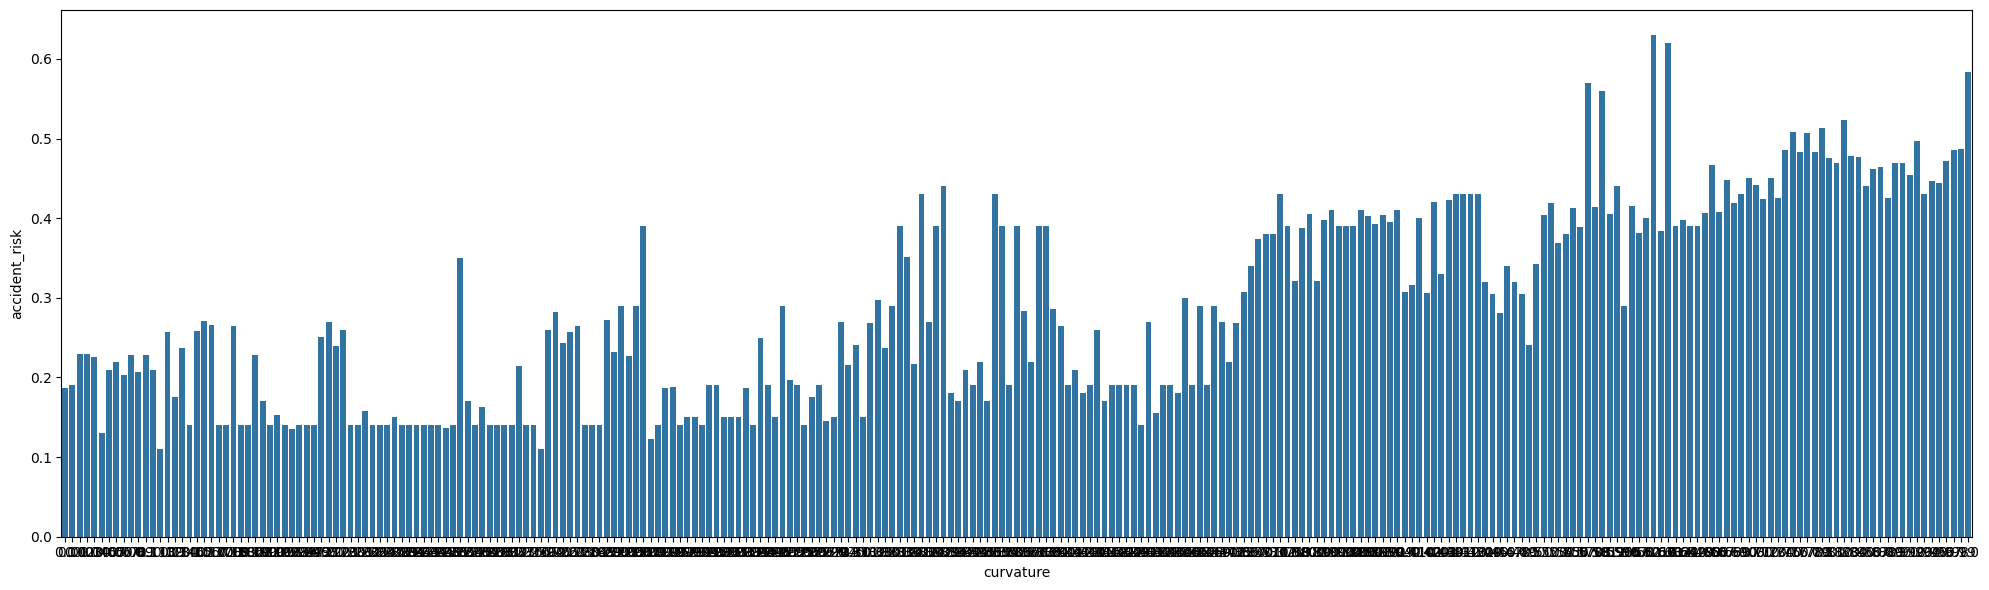

In [152]:
df_curvature = train.groupby(['curvature']).agg(
    {'accident_risk':'mean'}
).reset_index()
plt.figure(figsize=(20, 6))
sns.barplot(x = df_curvature['curvature'], y= df_curvature['accident_risk'])
plt.tight_layout()
plt.show()

- The plot does not actually seem to very beautiful, though from here we can observe that more curveate roads tend to be more risky

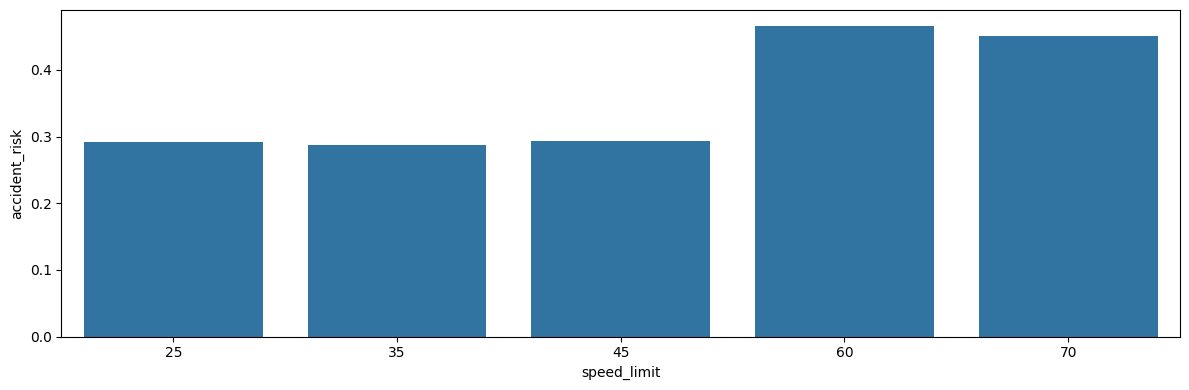

In [153]:
df_speed_limit = train.groupby(['speed_limit']).agg(
    {'accident_risk':'mean'}
).reset_index()
plt.figure(figsize=(12, 4))
sns.barplot(x = df_speed_limit['speed_limit'], y= df_speed_limit['accident_risk'])
plt.tight_layout()
plt.show()

- The faster it is allowed to drive - the more dangerius the road is -_-

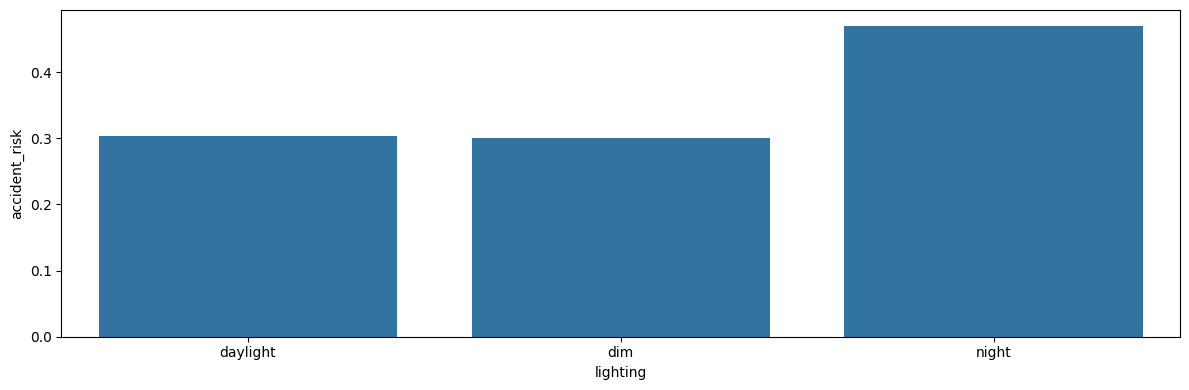

In [154]:
df_lightning = train.groupby(['lighting']).agg(
    {'accident_risk':'mean'}
).reset_index()
plt.figure(figsize=(12, 4))
sns.barplot(x = df_lightning['lighting'], y= df_lightning['accident_risk'])
plt.tight_layout()
plt.show()

- Driving at night is most risky. Though I still don't quite understand whether this value means night drive withought lights...

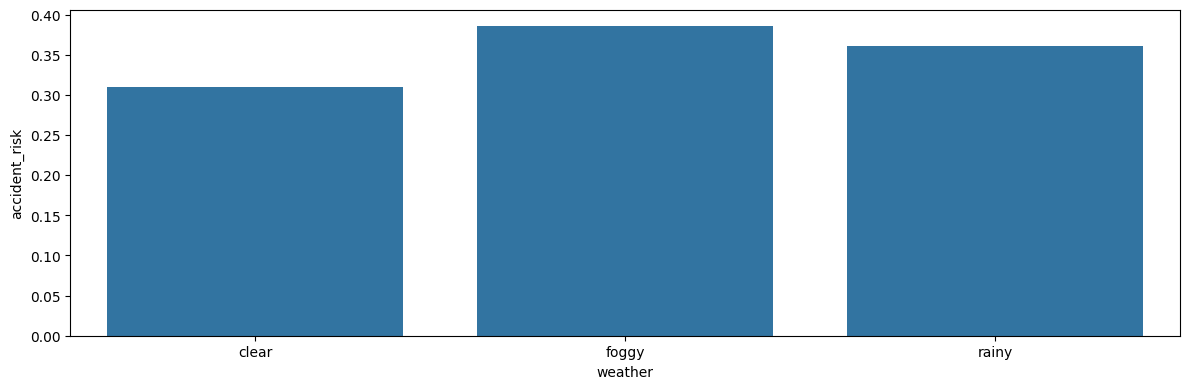

In [155]:
df_weather = train.groupby(['weather']).agg(
    {'accident_risk':'mean'}
).reset_index()
plt.figure(figsize=(12, 4))
sns.barplot(x = df_weather['weather'], y= df_weather['accident_risk'])
plt.tight_layout()
plt.show()

- Bad weather conditions are supposed to have a huge effect at **accident_risk**

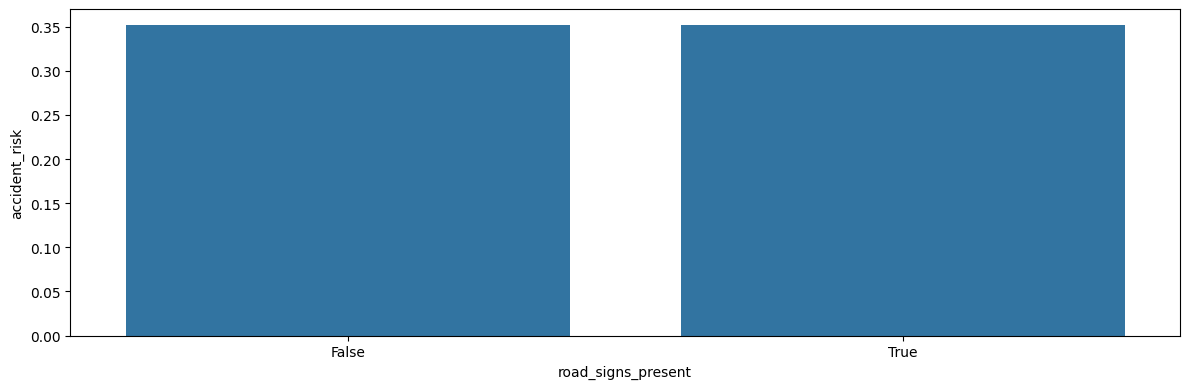

In [156]:
df_road_signs_present = train.groupby(['road_signs_present']).agg(
    {'accident_risk':'mean'}
).reset_index()
plt.figure(figsize=(12, 4))
sns.barplot(x = df_road_signs_present['road_signs_present'], y= df_road_signs_present['accident_risk'])
plt.tight_layout()
plt.show()

- Seems like sighns don't have meaning :(

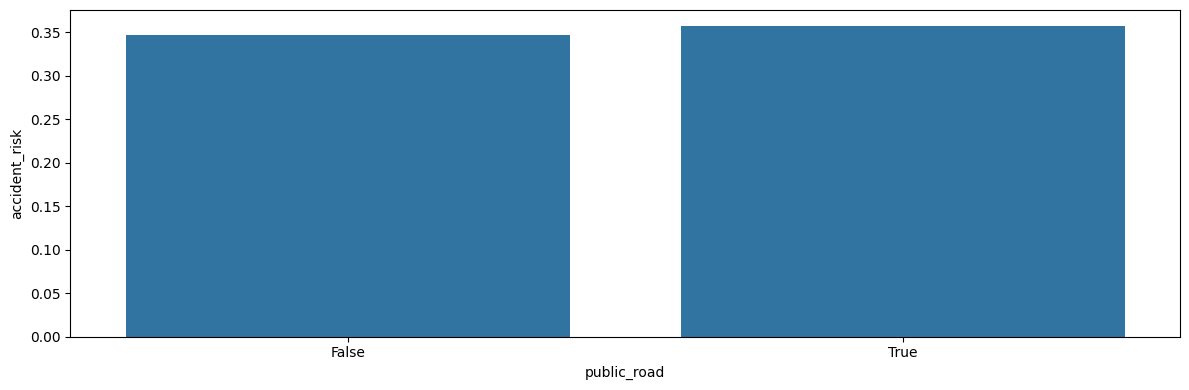

In [157]:
df_public_road = train.groupby(['public_road']).agg(
    {'accident_risk':'mean'}
).reset_index()
plt.figure(figsize=(12, 4))
sns.barplot(x = df_public_road['public_road'], y= df_public_road['accident_risk'])
plt.tight_layout()
plt.show()

- And the risk is not about public roads

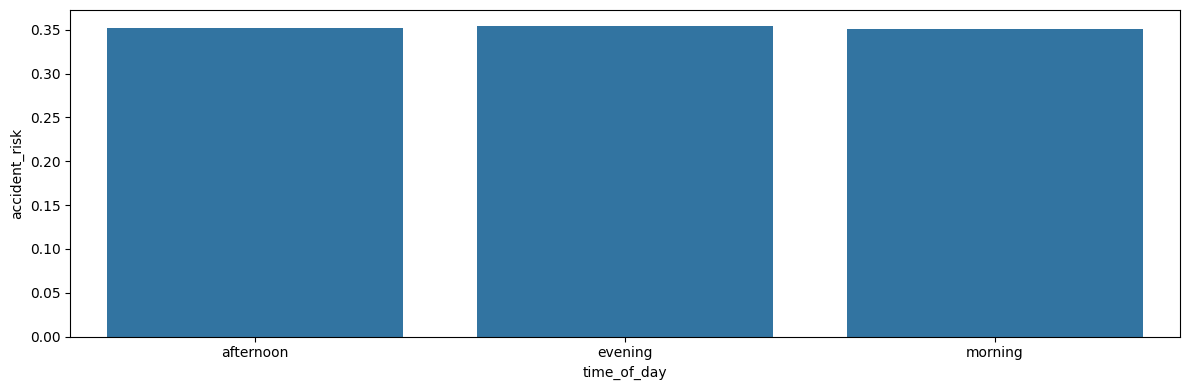

In [158]:
df_time_of_day = train.groupby(['time_of_day']).agg(
    {'accident_risk':'mean'}
).reset_index()
plt.figure(figsize=(12, 4))
sns.barplot(x = df_time_of_day['time_of_day'], y= df_time_of_day['accident_risk'])
plt.tight_layout()
plt.show()

- Same thing

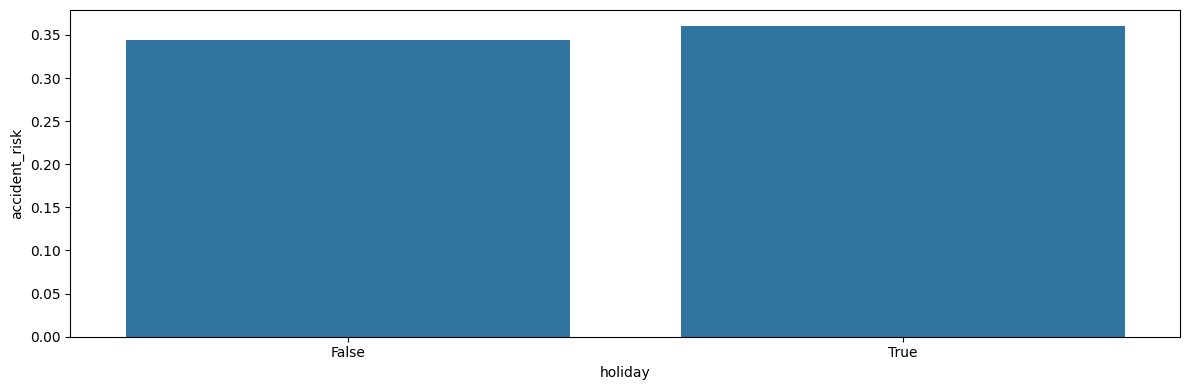

In [159]:
df_holiday = train.groupby(['holiday']).agg(
    {'accident_risk':'mean'}
).reset_index()
plt.figure(figsize=(12, 4))
sns.barplot(x = df_holiday['holiday'], y= df_holiday['accident_risk'])
plt.tight_layout()
plt.show()

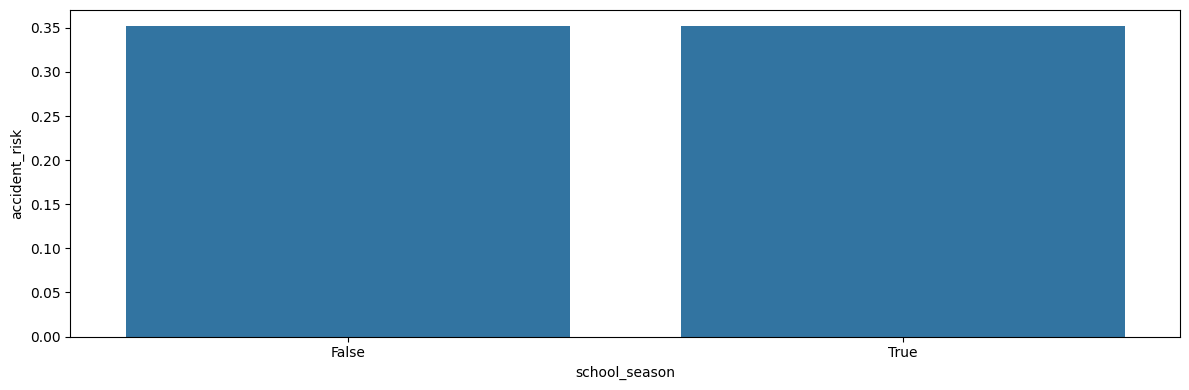

In [160]:
df_school_season = train.groupby(['school_season']).agg(
    {'accident_risk':'mean'}
).reset_index()
plt.figure(figsize=(12, 4))
sns.barplot(x = df_school_season['school_season'], y= df_school_season['accident_risk'])
plt.tight_layout()
plt.show()

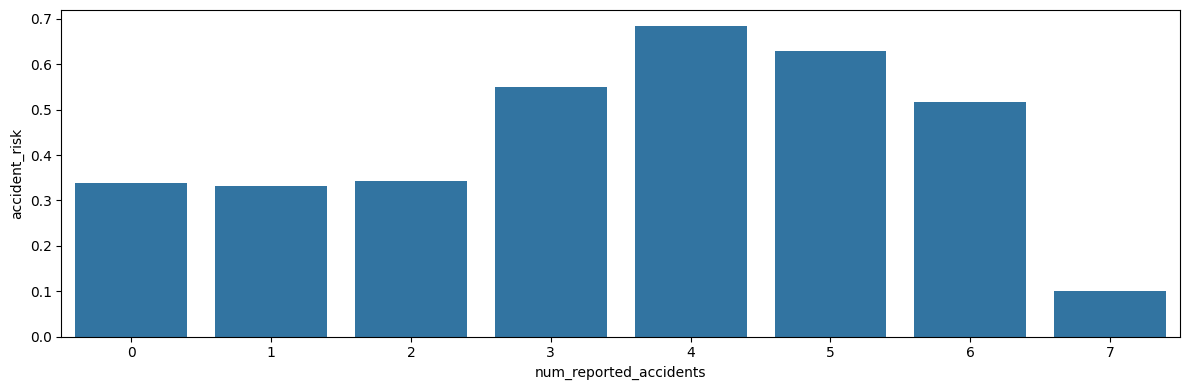

In [161]:
df_num_reported_accidents = train.groupby(['num_reported_accidents']).agg(
    {'accident_risk':'mean'}
).reset_index()
plt.figure(figsize=(12, 4))
sns.barplot(x = df_num_reported_accidents['num_reported_accidents'], y= df_num_reported_accidents['accident_risk'])
plt.tight_layout()
plt.show()

- This unclear feature seems to effect the risk

# 4. Correlations

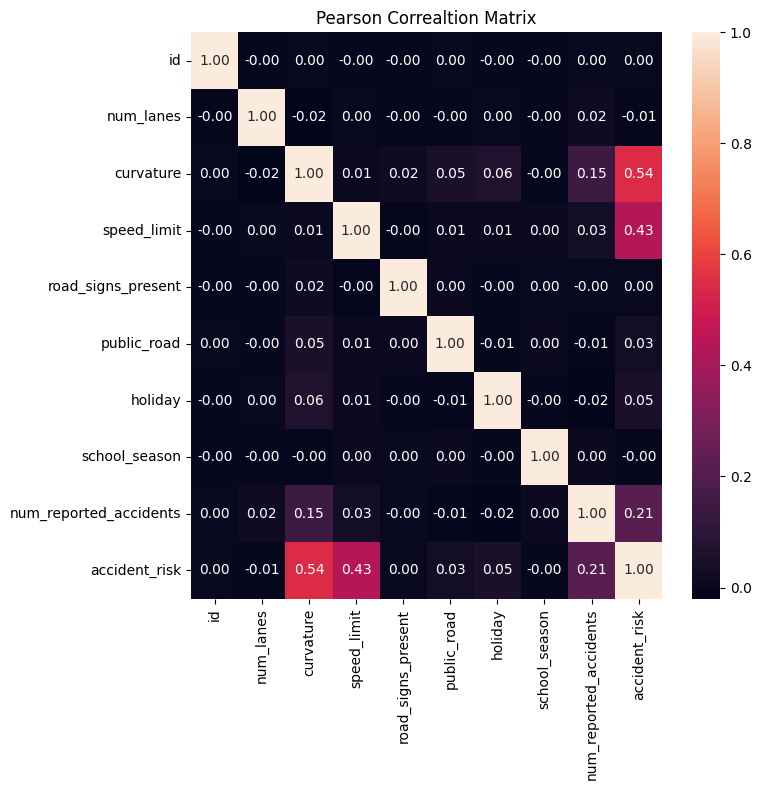

In [162]:
train_pearson_corr = train.corr(numeric_only=True)
train_spearman_corr = train.corr(method='spearman', numeric_only=True)

plt.figure(figsize=(8,8))
sns.heatmap(train_pearson_corr, annot=True, fmt='.2f')
plt.title('Pearson Correaltion Matrix')
plt.tight_layout()
plt.show()


We can capture some linear correlations with target:
- **curvature** (0.54)
- **speed_limit** (0.43)
- **num_reported_accidents** (0.21)

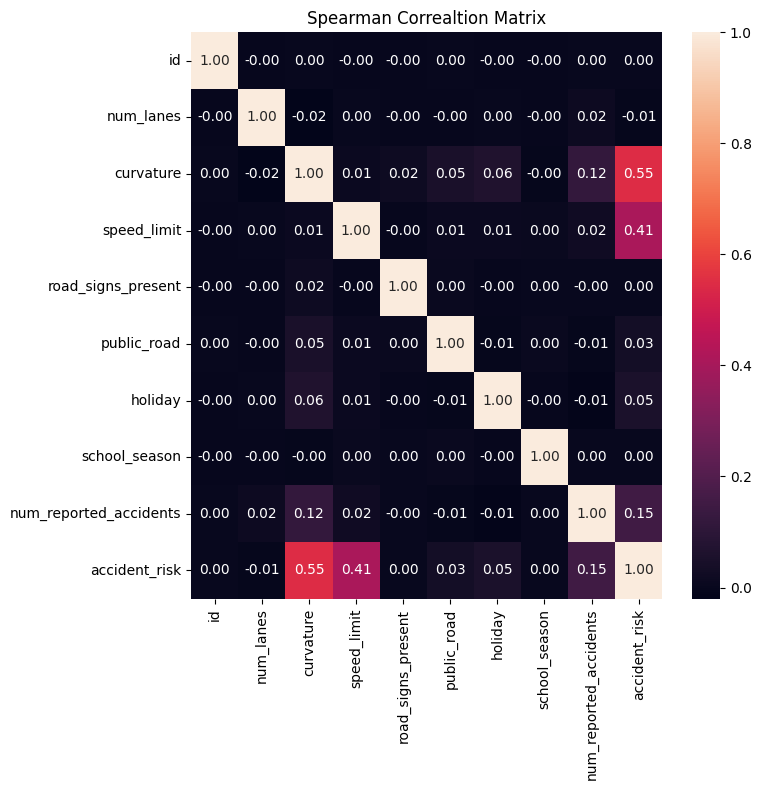

In [163]:
plt.figure(figsize=(8,8))
sns.heatmap(train_spearman_corr, annot=True, fmt='.2f')
plt.title('Spearman Correaltion Matrix')
plt.tight_layout()
plt.show()


Yep, exactly the situation same catching non-linear correlations

In [164]:
train

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51


In [165]:
from category_encoders import TargetEncoder
te = TargetEncoder()
train = te.fit_transform(train, train['accident_risk'])
train

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,0.357456,2,0.06,35,0.302923,0.361494,False,True,0.351428,False,True,1,0.13
1,1,0.357456,4,0.99,35,0.302923,0.310060,True,False,0.354736,True,True,0,0.35
2,2,0.349997,4,0.63,70,0.300109,0.310060,False,True,0.350966,True,False,2,0.30
3,3,0.349734,4,0.07,35,0.300109,0.361494,True,True,0.350966,False,False,1,0.21
4,4,0.349997,1,0.58,60,0.302923,0.386305,False,False,0.354736,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,0.349734,4,0.10,70,0.302923,0.386305,True,True,0.351428,False,False,2,0.32
517750,517750,0.349997,4,0.47,35,0.302923,0.361494,True,True,0.350966,False,False,1,0.26
517751,517751,0.357456,4,0.62,25,0.302923,0.386305,False,False,0.351428,False,True,0,0.19
517752,517752,0.349734,3,0.63,25,0.470467,0.310060,True,False,0.351428,True,True,3,0.51


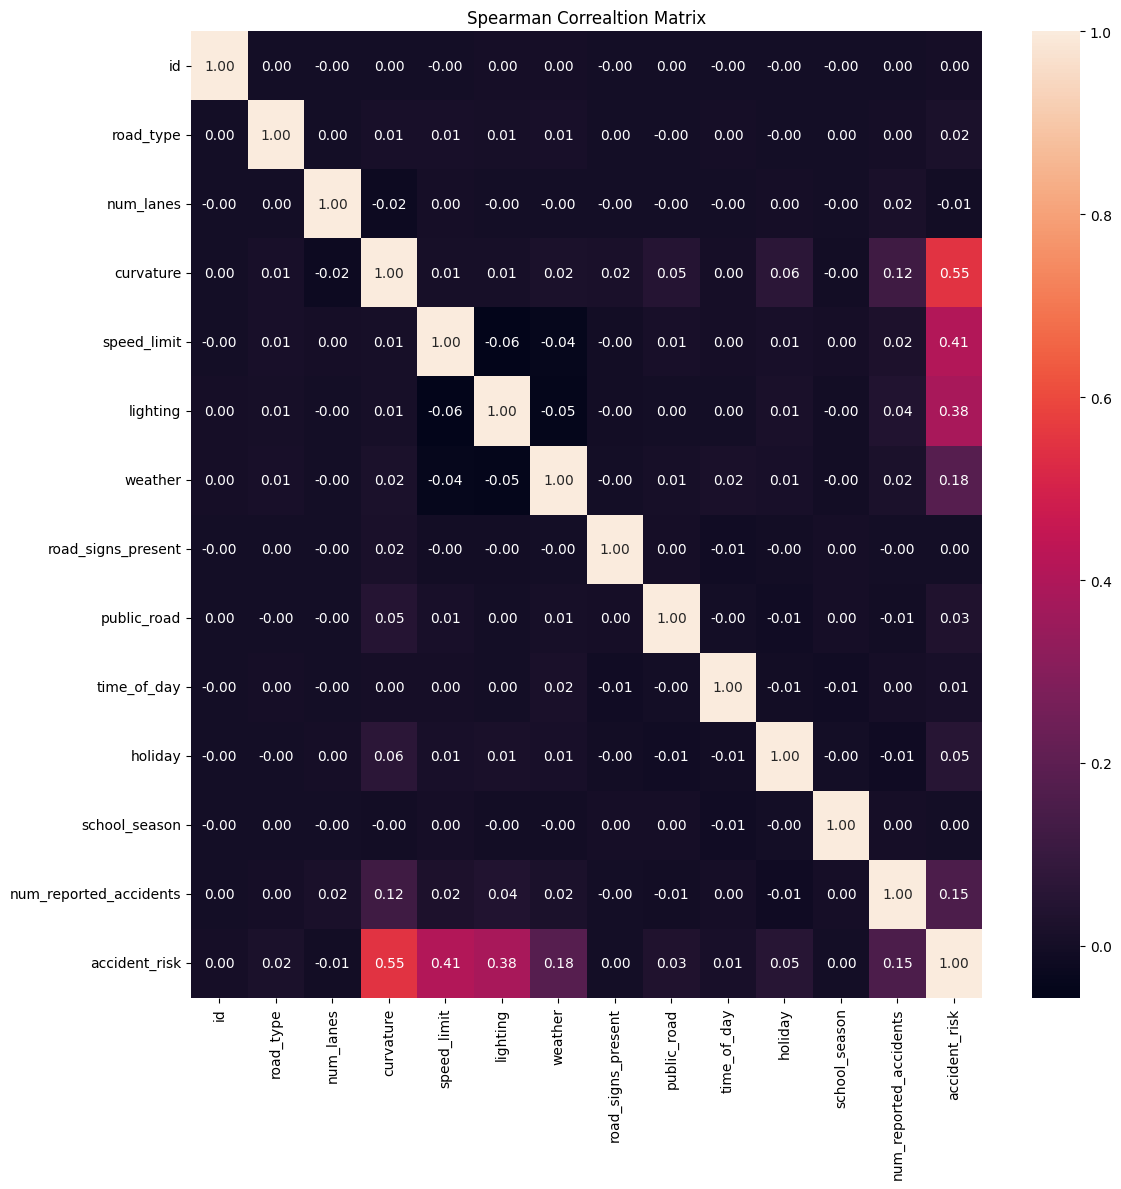

In [166]:
train_spearman_corr = train.corr(method='spearman')
plt.figure(figsize=(12,12))
sns.heatmap(train_spearman_corr, annot=True, fmt='.2f')
plt.title('Spearman Correaltion Matrix')
plt.tight_layout()
plt.show()


Such a way we can highlight 5 main features correlated with the target:
- curvature (0.55)
- speed_limit(0.41)
- lighting (0.38)
- weather (0.18)
- num_reported_accidents(0.15)